## **dataloader**

In [142]:
import torch
from torch.utils.data import DataLoader as torch_dataloader
from torch.utils.data import Dataset as torch_dataset
import numpy as np
import matplotlib.pyplot as plt
import skimage
import skimage.io as io
import glob
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.nn.functional as nnF
import torch.optim as optim
from torch.utils.data import DataLoader as torch_dataloader
from torch.utils.data import Dataset as torch_dataset
import torchvision
from torchvision import datasets, transforms
import torchvision.models as tv_models
import skimage
import skimage.io as io
import glob
from tqdm import tqdm


##%%
class MyDataset(torch_dataset):
    def __init__(self, path, filenamelist, labellist):
        self.path=path
        self.filenamelist=filenamelist
        self.labellist=labellist
    def __len__(self):
        return len(self.filenamelist)
    def __getitem__(self, idx):
        I=io.imread(self.path+self.filenamelist[idx])
        I=skimage.util.img_as_float32(I)
        I = I.reshape(1,I.shape[0],I.shape[1])
        I = torch.tensor(I, dtype=torch.float32)
        I = I.expand(3, I.shape[1],I.shape[2])
        label=torch.tensor(self.labellist[idx], dtype=torch.int64)
        label=label.reshape(-1)
        return I, label
##%%
def get_dataloader(path = 'C:\\Users\\rjv71\\Downloads\\S224\\'):
    df_train=pd.read_csv(path+'train.csv')
    dataset_train = MyDataset(path, df_train['filename'].values, df_train['label'].values)
    loader_train = torch_dataloader(dataset_train, batch_size=32, num_workers=0,
                                    shuffle=True, pin_memory=True)

    df_val=pd.read_csv(path+'val.csv')
    dataset_val = MyDataset(path, df_val['filename'].values, df_val['label'].values)
    loader_val = torch_dataloader(dataset_val, batch_size=32, num_workers=0,
                                    shuffle=True, pin_memory=True)

    df_test=pd.read_csv(path+'test.csv')
    dataset_test = MyDataset(path, df_test['filename'].values, df_test['label'].values)
    loader_test = torch_dataloader(dataset_test, batch_size=32, num_workers=0,
                                    shuffle=True, pin_memory=True)

    return loader_train, dataset_train, loader_val, dataset_val, loader_test, dataset_test

In [143]:
# from google.colab import files
# uploaded = files.upload()  # Select the zip file here




In [144]:
import zipfile

with zipfile.ZipFile("S224.zip", 'r') as zip_ref:
    zip_ref.extractall("S224")

import os

print(os.listdir())
print("S224 contents:", os.listdir("S224"))

loader_train,dataset_train,loader_val,dataset_val,loader_test,dataset_test = get_dataloader(path="S224/S224/")


['.config', 'CNN_LS_Pytorch_epoch39.pt', 'CNN_LS_Pytorch_epoch42.pt', 'CNN_LS_Pytorch_epoch25.pt', 'CNN_LS_Pytorch_epoch50.pt', 'CNN_LS_Pytorch_epoch30.pt', 'CNN_LS_Pytorch_epoch10.pt', 'CNN_LS_Pytorch_epoch28.pt', 'CNN_LS_Pytorch_epoch3.pt', 'CNN_LS_Pytorch_epoch0.pt', 'CNN_LS_Pytorch_epoch14.pt', 'CNN_LS_Pytorch_epoch45.pt', 'S224', 'CNN_LS_Pytorch_epoch46.pt', 'CNN_LS_Pytorch_epoch49.pt', 'CNN_LS_Pytorch_epoch34.pt', 'CNN_LS_Pytorch_epoch4.pt', 'CNN_LS_Pytorch_epoch41.pt', 'CNN_LS_Pytorch_epoch48.pt', 'CNN_LS_Pytorch_epoch33.pt', 'CNN_LS_Pytorch_epoch6.pt', 'CNN_LS_Pytorch_epoch5.pt', 'CNN_LS_Pytorch_epoch32.pt', 'CNN_LS_Pytorch_epoch37.pt', 'CNN_LS_Pytorch_epoch35.pt', 'CNN_LS_Pytorch_epoch1.pt', 'CNN_LS_Pytorch_epoch16.pt', 'CNN_LS_Pytorch_epoch9.pt', 'CNN_LS_Pytorch_epoch36.pt', 'CNN_LS_Pytorch_epoch7.pt', 'CNN_LS_Pytorch_epoch43.pt', 'CNN_LS_Pytorch_epoch22.pt', 'CNN_LS_Pytorch_epoch44.pt', 'CNN_LS_Pytorch_epoch19.pt', 'S224.zip', 'CNN_LS_Pytorch_epoch15.pt', 'CNN_LS_Pytorch_epo

## **model**

In [145]:
from torchvision.models import ResNet18_Weights

class COVIDClassifier(nn.Module):
    def __init__(self):
        super(COVIDClassifier, self).__init__()

        self.backbone = tv_models.resnet18(pretrained=False)
        self.backbone.fc = nn.Linear(512, 1)

    def get_trainable_parameters(self):
        paramList=list(self.backbone.parameters())+list(self.backbone.fc.parameters())
        return paramList

    def forward(self,x):
        z = self.backbone(x)
        return z


In [146]:
def save_checkpoint(filename, model, optimizer, result, epoch):
    torch.save({'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'result':result},
               filename)
    print('saved:', filename)

In [147]:
def train(model, device, optimizer, dataloader, epoch):
    model.train()
    loss_train = 0
    acc_train = 0
    for batch_idx, (X, Y) in enumerate(dataloader):
        X, Y = X.to(device), Y.view(-1, 1).float().to(device)
        optimizer.zero_grad()
        Z = model(X)
        loss = nnF.binary_cross_entropy_with_logits(Z, Y)
        loss.backward()
        optimizer.step()
        loss_train += loss.item()
        Yp = (Z.data > 0).to(torch.int64)
        acc_train += torch.sum(Yp == Y.to(torch.int64)).item()
        if batch_idx % 10 == 0:
            print('Train Epoch: {} [{:.0f}%]\tLoss: {:.6f}'.format(
                epoch, 100. * batch_idx / len(dataloader), loss.item()))
    loss_train /= len(dataloader)
    acc_train /= len(dataloader.dataset)
    return loss_train, acc_train

In [148]:
def test(model, device, dataloader):
    model.eval()#set model to evaluation mode
    loss_test=0
    acc_test =0
    Confusion=np.zeros((2,2))
    with torch.no_grad():
        for batch_idx, (X, Y) in enumerate(dataloader):
            Y = Y.to(X.dtype)
            X, Y = X.to(device), Y.to(device)
            Z = model(X)
            loss = nnF.binary_cross_entropy_with_logits(Z, Y)
            loss_test+=loss.item()
            Yp = (Z.data > 0).to(torch.int64)
            Y = Y.to(torch.int64)
            acc_test+= torch.sum(Yp==Y).item()
            for i in range(0, 2):
                for j in range(0, 2):
                    Confusion[i,j]+=torch.sum((Y==i)&(Yp==j)).item()
    loss_test/=len(dataloader)
    acc_test/=len(dataloader.dataset)
    Sens=np.zeros(2)
    Prec=np.zeros(2)
    for n in range(0, 2):
        TP=Confusion[n,n]
        FN=np.sum(Confusion[n,:])-TP
        FP=np.sum(Confusion[:,n])-TP
        Sens[n]=TP/(TP+FN)
        Prec[n]=TP/(TP+FP)
    Acc = Confusion.diagonal().sum()/Confusion.sum()
    return loss_test, acc_test, (Confusion, Acc, Sens, Prec)

In [149]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print('device', device)
model=COVIDClassifier()
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.BCEWithLogitsLoss()

(x,label)=dataset_train[0]
x=x.view(1,3,224,224).to(device)
z=model(x)

loss_train_list=[]
acc_train_list=[]
loss_val_list=[]
acc_val_list=[]
epoch_save=-1

device cuda:0


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [150]:
def plot_result(loss_train_list, acc_train_list,
                loss_val_list, acc_val_list):
    fig, ax = plt.subplots(1, 2, figsize=(12,6))
    ax[0].set_title('loss v.s. epoch',fontsize=16)
    ax[0].plot(loss_train_list, '-b', label='training loss')
    ax[0].plot(loss_val_list, '-g', label='validation loss')
    ax[0].set_xlabel('epoch',fontsize=16)
    ax[0].legend(fontsize=16)
    ax[0].grid(True)
    ax[1].set_title('accuracy v.s. epoch',fontsize=16)
    ax[1].plot(acc_train_list, '-b', label='training accuracy')
    ax[1].plot(acc_val_list, '-g', label='validation accuracy')
    ax[1].set_xlabel('epoch',fontsize=16)
    ax[1].legend(fontsize=16)
    ax[1].grid(True)
    return fig, ax

In [151]:
import time
from IPython import display

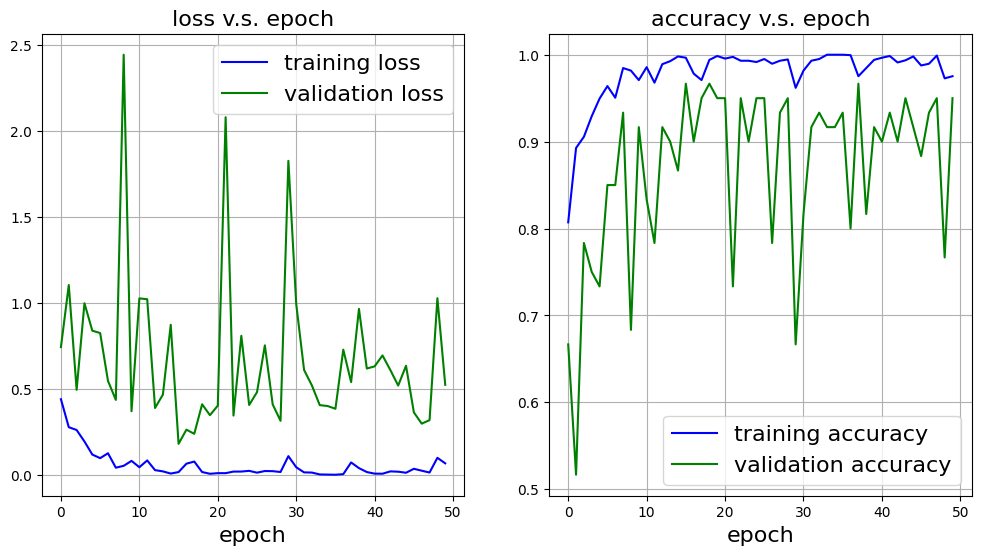

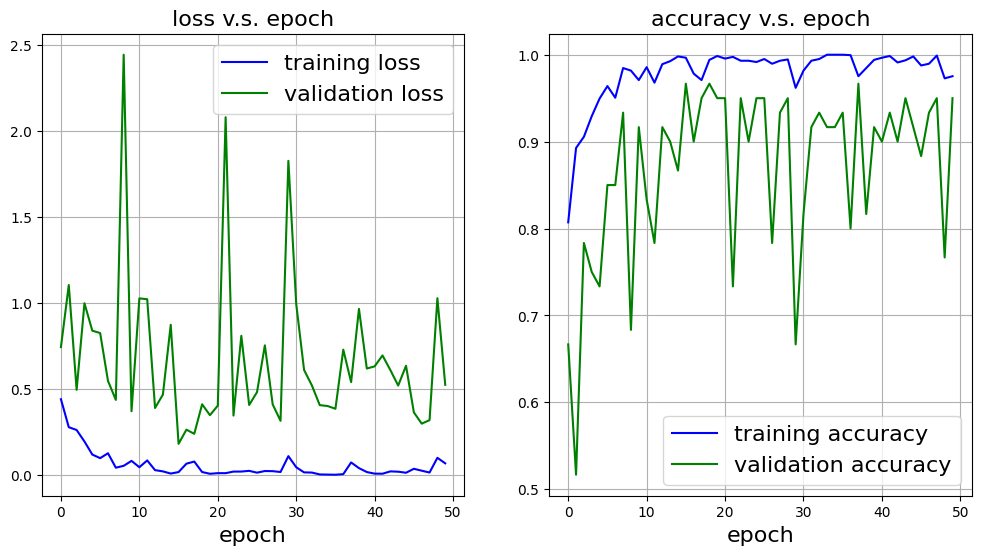

In [152]:
for epoch in range(epoch_save+1, epoch_save+51):
    t0=time.time()
    #Training
    loss_train, acc_train =train(model, device, optimizer, loader_train, epoch)
    loss_train_list.append(loss_train)
    acc_train_list.append(acc_train)
    print('epoch', epoch, 'training loss:', loss_train, 'acc:', acc_train)
    #Validation
    loss_val, acc_val, other_val = test(model, device, loader_val)
    loss_val_list.append(loss_val)
    acc_val_list.append(acc_val)
    print('epoch', epoch, 'validation loss:', loss_val, 'acc:', acc_val)
    t1=time.time()
    print("time cost", t1-t0)
    #Save the model
    result = (loss_train_list, acc_train_list,
              loss_val_list, acc_val_list, other_val)
    save_checkpoint('CNN_LS_Pytorch_epoch'+str(epoch)+'.pt', model, optimizer, result, epoch)
    epoch_save=epoch
    #Show the result
    display.clear_output(wait=False)
    plt.close('all')
    fig, ax = plot_result(loss_train_list, acc_train_list,
                          loss_val_list, acc_val_list)
    display.display(fig)

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'loss v.s. epoch'}, xlabel='epoch'>,
        <Axes: title={'center': 'accuracy v.s. epoch'}, xlabel='epoch'>],
       dtype=object))

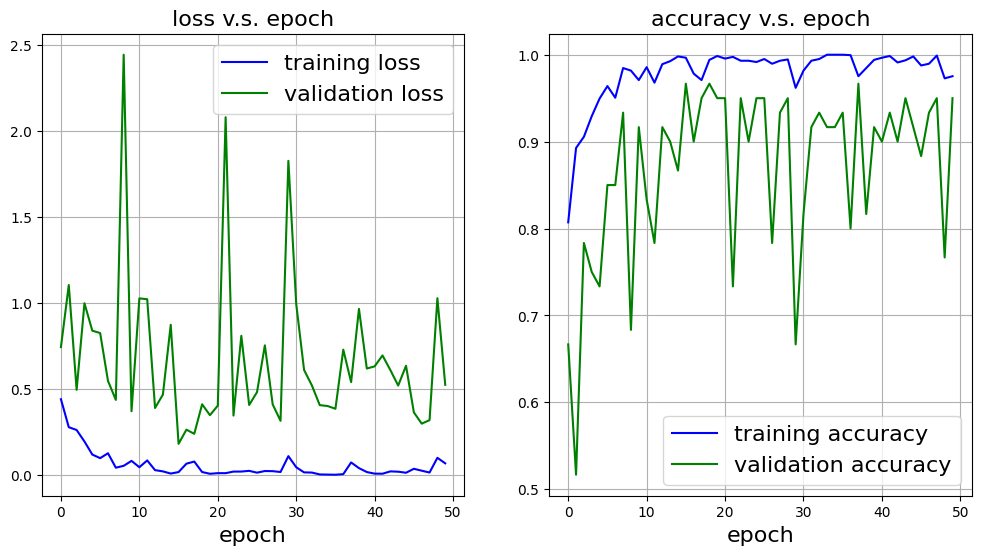

In [153]:
plot_result(loss_train_list, acc_train_list,
            loss_val_list, acc_val_list)

# LETS SEE HOW OUR BEST MODEL HAS PERFORMED

In [154]:
best_ep= np.array(acc_val_list).argmax()
best_ep

np.int64(15)

In [155]:
poch_save=best_ep
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load('CNN_LS_Pytorch_epoch'+str(epoch_save)+'.pt', map_location=device, weights_only=False)
model=COVIDClassifier()
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()
(loss_train_list, acc_train_list,
 loss_val_list, acc_val_list, other_val) = checkpoint['result']

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [156]:
loss_val, acc_val, (Confusion, Acc, Sens, Prec) = test(model, device, loader_test)
Confusion_sens=Confusion.copy()
for n in range(0, 2):
    Confusion_sens[n,:]/=np.sum(Confusion[n,:])
Confusion_prec=Confusion.copy()
for n in range(0, 2):
    Confusion_prec[:,n]/=np.sum(Confusion[:,n])
print('Accuracy (average)', acc_val)
print('Accuracy (average)', Acc)
print('Sensitivity', Sens)
print('Precision', Prec)
print('Confusion_sens \n', Confusion_sens)
print('Confusion_prec \n', Confusion_prec)

Accuracy (average) 0.9425
Accuracy (average) 0.9425
Sensitivity [0.96  0.925]
Precision [0.92753623 0.95854922]
Confusion_sens 
 [[0.96  0.04 ]
 [0.075 0.925]]
Confusion_prec 
 [[0.92753623 0.04145078]
 [0.07246377 0.95854922]]


# **Visualize the models trained in (2)&(3) using two CAM methods (GradCAM, EigenCAM, etc)**

In [159]:
# !pip install grad-cam



In [157]:
import random
from pytorch_grad_cam import GradCAM, EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget
from pytorch_grad_cam.utils.image import preprocess_image
from torchvision.models import resnet18, ResNet18_Weights




covid_images = []
noncovid_images = []

# Collect COVID and Non-COVID images from the test set
for img, label in dataset_test:
    if label == 1 and len(covid_images) < 10:
        covid_images.append((img, label))
    elif label == 0 and len(noncovid_images) < 10:
        noncovid_images.append((img, label))
    if len(covid_images) == 10 and len(noncovid_images) == 10:
        break

print(f"Selected {len(covid_images)} COVID and {len(noncovid_images)} Non-COVID images for CAM.")
selected_samples = covid_images + noncovid_images
random.shuffle(selected_samples)

Selected 10 COVID and 10 Non-COVID images for CAM.


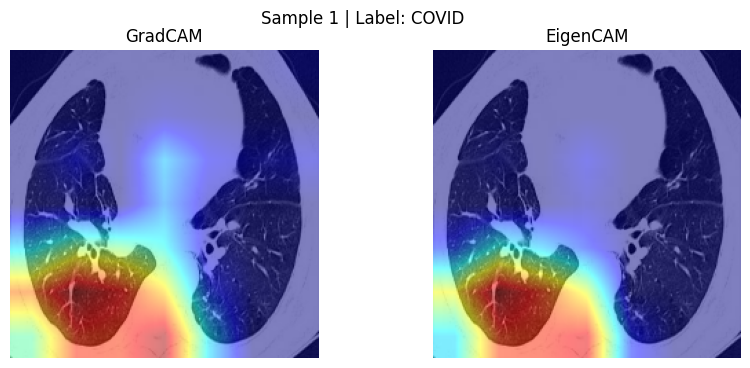

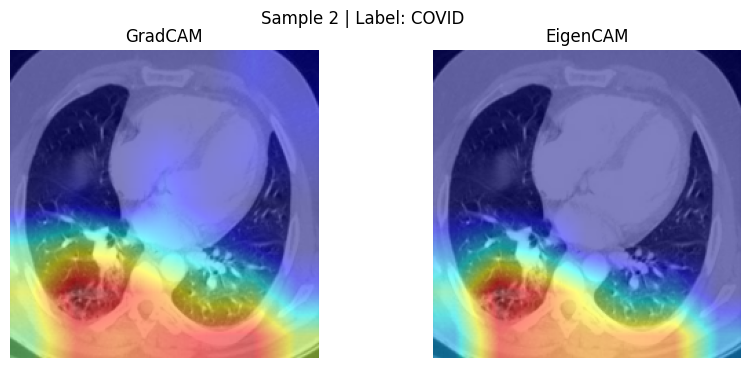

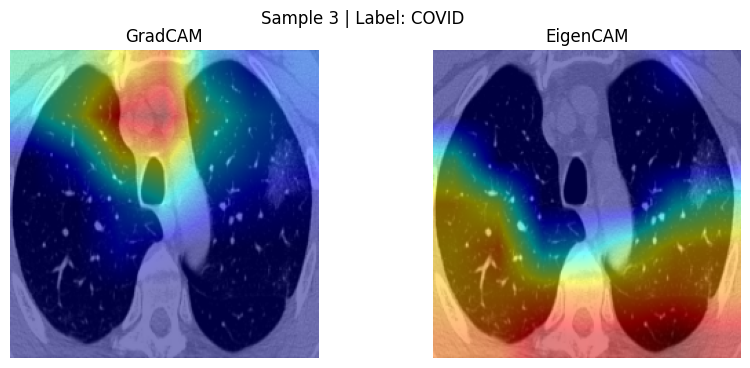

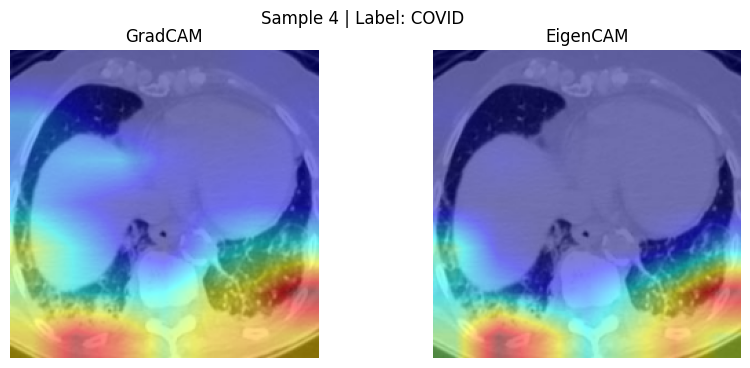

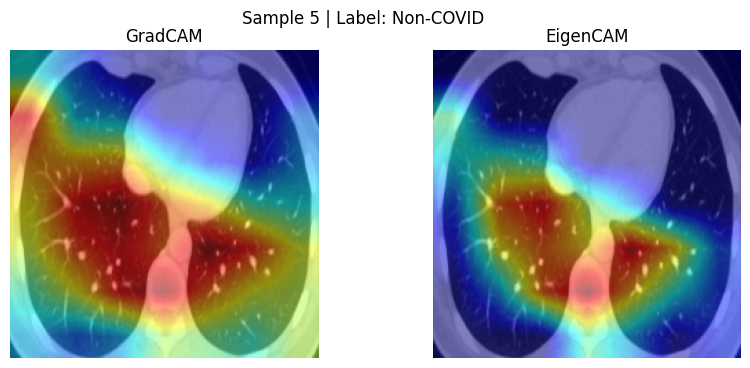

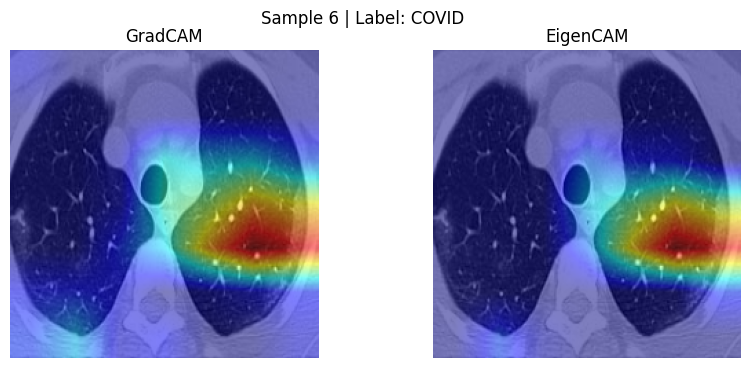

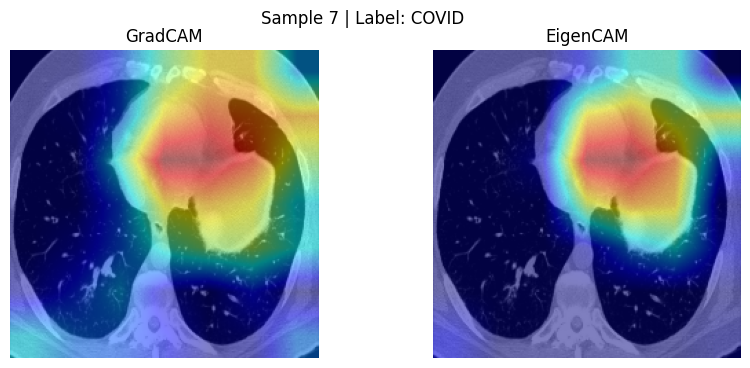

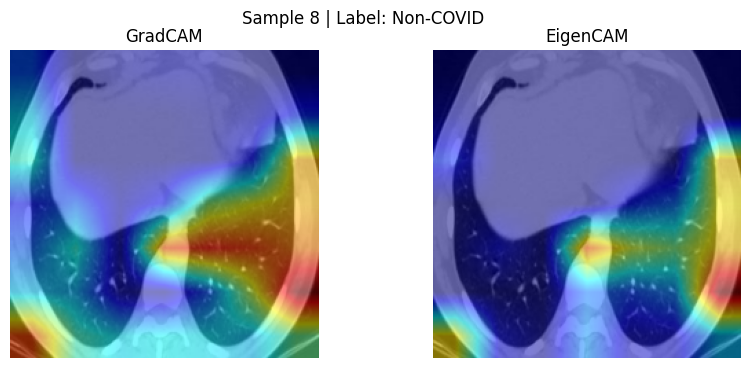

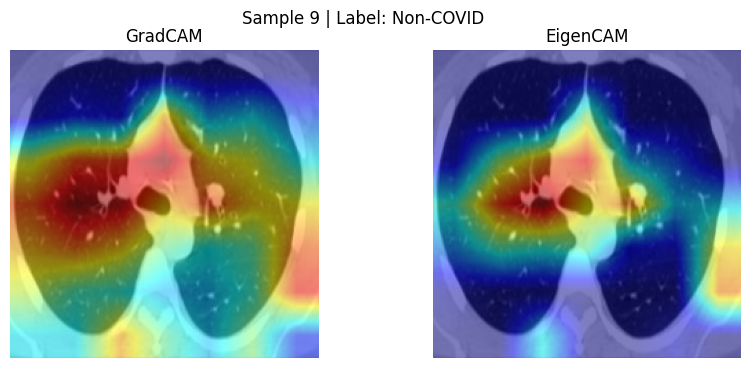

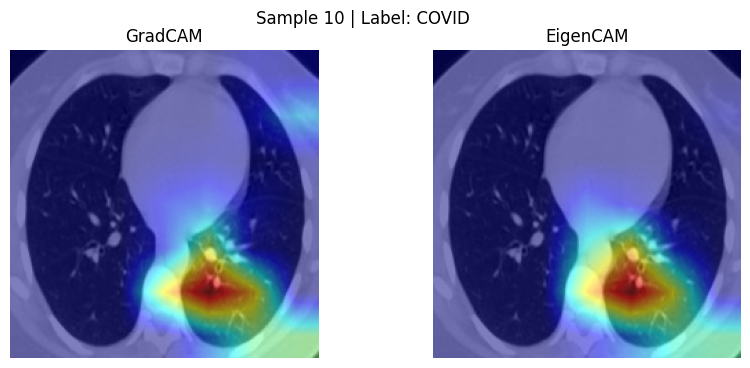

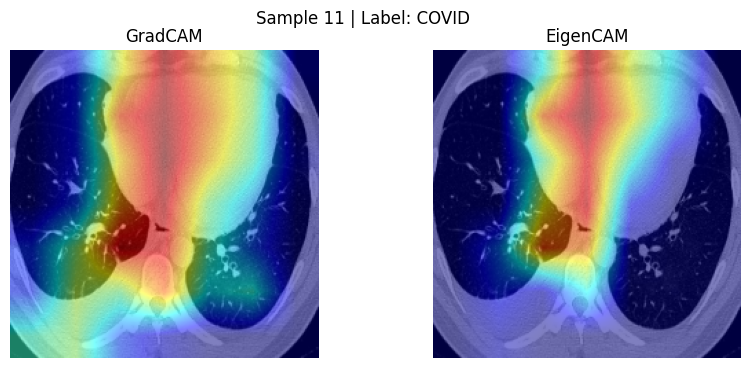

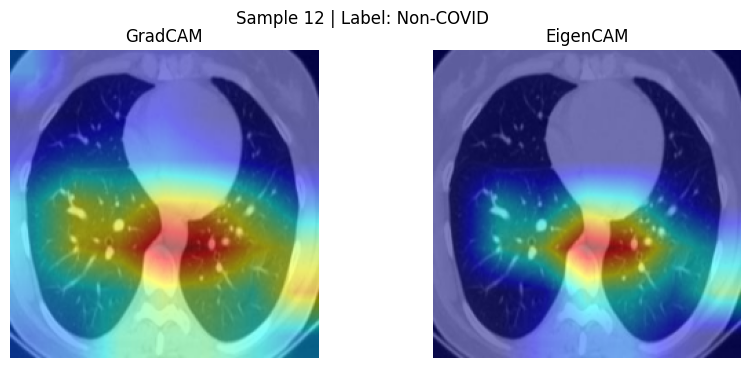

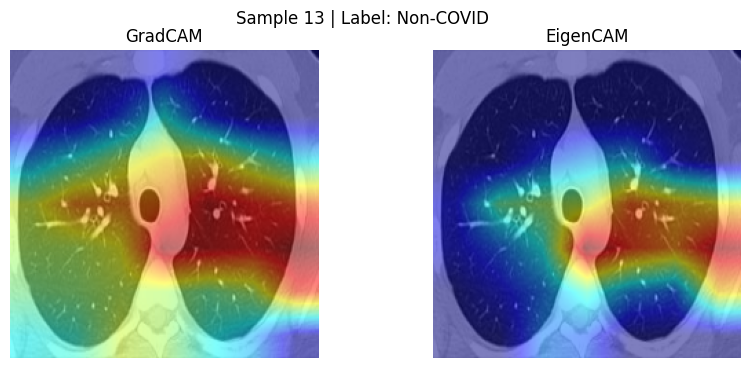

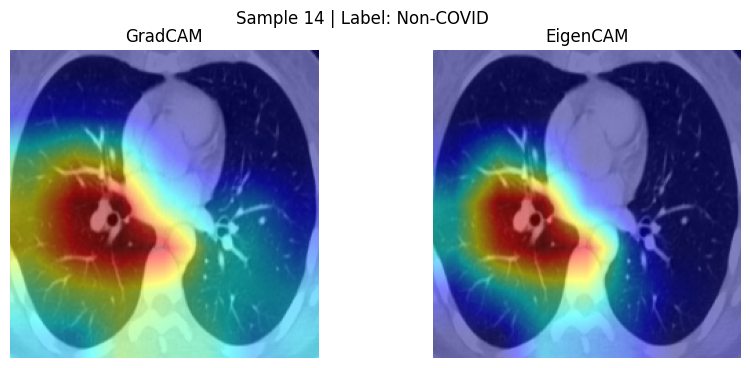

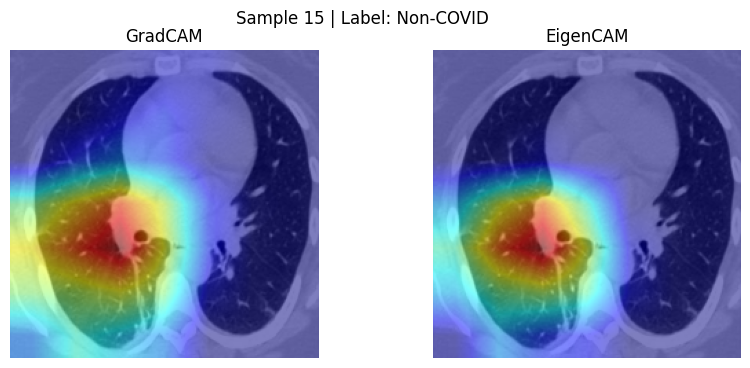

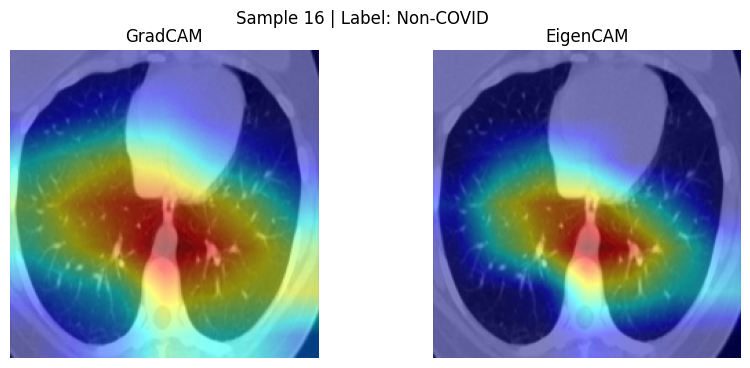

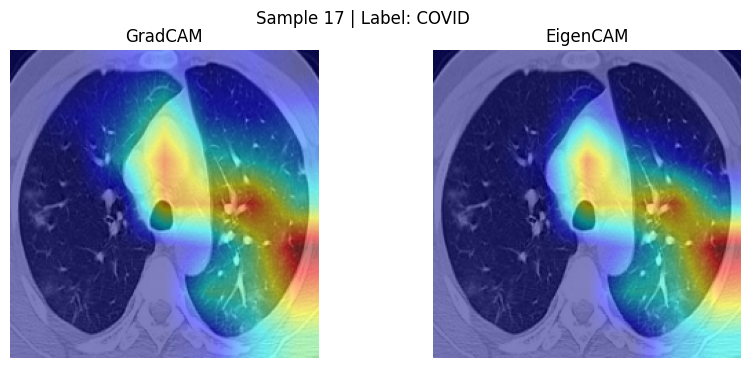

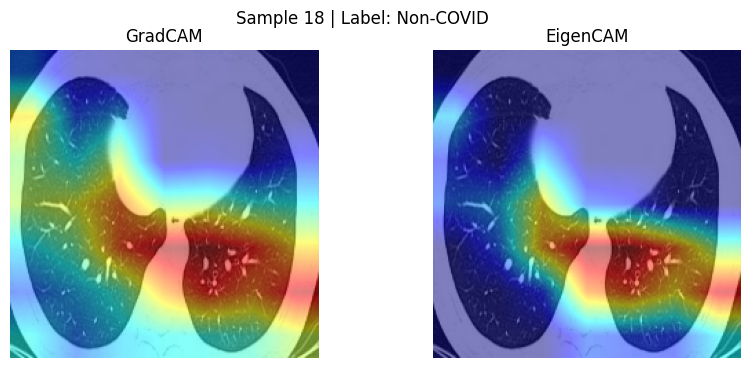

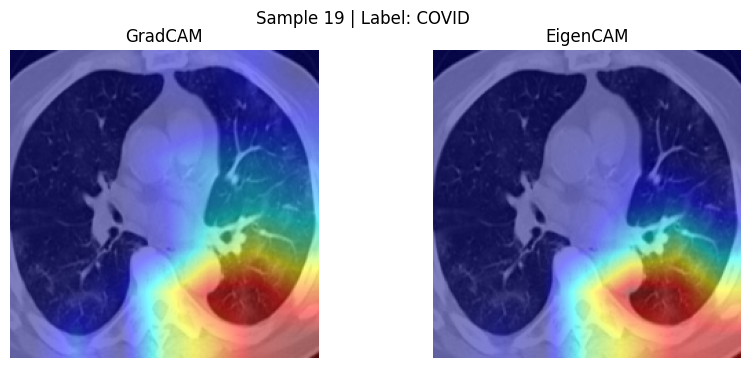

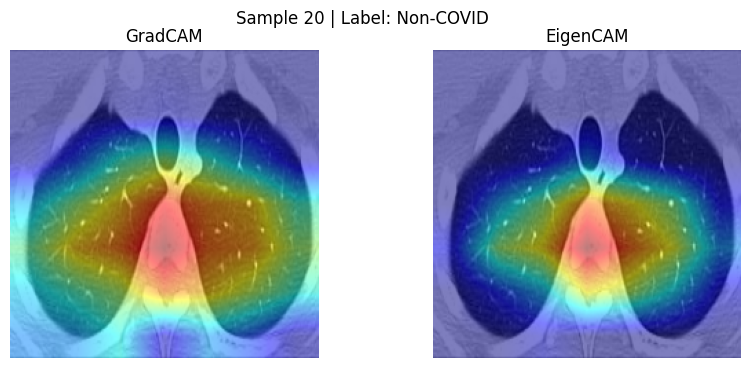

In [158]:


# Define the target layer for CAM (last conv layer in ResNet18)
target_layer = model.backbone.layer4[-1]

# CAM
gradcam = GradCAM(model=model, target_layers=[target_layer])
eigencam = EigenCAM(model=model, target_layers=[target_layer])

# Visualize
for idx, (img, label) in enumerate(selected_samples):
    input_tensor = img.unsqueeze(0).to(device)
    rgb_img = img.permute(1, 2, 0).numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min() + 1e-8)  # Normalize

    target = [BinaryClassifierOutputTarget(category=int(label))]

    # GradCAM
    grayscale_gc = gradcam(input_tensor=input_tensor, targets=target)[0]
    cam_gc = show_cam_on_image(rgb_img, grayscale_gc, use_rgb=True)

    # EigenCAM
    grayscale_ec = eigencam(input_tensor=input_tensor, targets=target)[0]
    cam_ec = show_cam_on_image(rgb_img, grayscale_ec, use_rgb=True)

    plt.figure(figsize=(10,4))
    plt.suptitle(f"Sample {idx+1} | Label: {'COVID' if label==1 else 'Non-COVID'}")
    plt.subplot(1,2,1)
    plt.imshow(cam_gc)
    plt.title("GradCAM")
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.imshow(cam_ec)
    plt.title("EigenCAM")
    plt.axis('off')
    plt.show()


In [160]:
target_layers = [model.backbone.layer4[-1]]

**Load an image from Test set**

In [161]:
def normalize_color_image(I):
    I_max = I.max(axis=(0,1), keepdims=True)
    I_min = I.min(axis=(0,1), keepdims=True)
    I = (I - I_min)/(I_max-I_min)
    return I

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

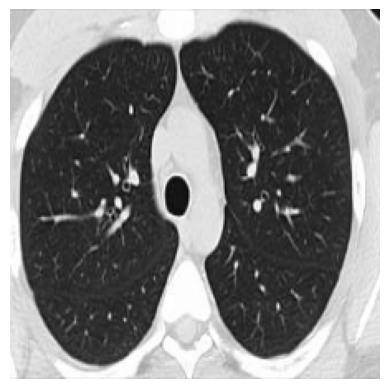

In [162]:
(x,label)=dataset_test[0]
x = x.detach().cpu().numpy().squeeze().transpose(1,2,0)
x = normalize_color_image(x)
fig, ax = plt.subplots()
ax.imshow(x)
ax.axis('off')

In [164]:
image_gray = x
image_shape = image_gray.shape

if len(image_shape) == 2 or (len(image_shape) == 3 and image_shape[2] == 1):
    image_gray = image_gray.reshape(image_shape[0], image_shape[1], 1)
    image_color = np.concatenate([image_gray, image_gray, image_gray], axis=2)
else:
    image_color = image_gray

In [165]:
image_input=torch.tensor(image_color).permute(2,0,1)
image_input=image_input.reshape(1,3,224,224)
image_input.shape

torch.Size([1, 3, 224, 224])

In [166]:
class ClassifierOutputTarget:
    def __init__(self, category):
        self.category = category

    def __call__(self, model_output):
            return model_output


In [167]:
image_input = image_input.cuda()
model_output = model(image_input)
model_output = model_output.cpu()

In [170]:
cam = GradCAM(model=model, target_layers=target_layers)
target = ClassifierOutputTarget(category=0)
grayscale_cam = cam(input_tensor=image_input, targets=[target])
grayscale_cam.shape

(1, 224, 224)

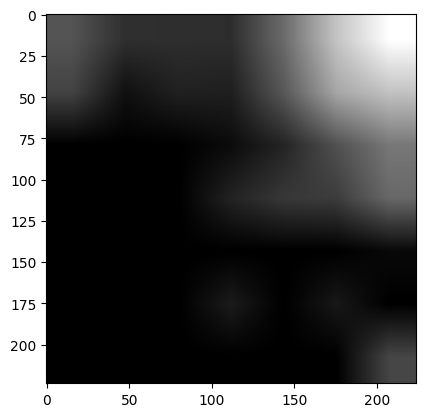

In [172]:
plt.imshow(grayscale_cam, cmap='gray')

In [173]:
cam_image = show_cam_on_image(x, grayscale_cam, use_rgb=True)

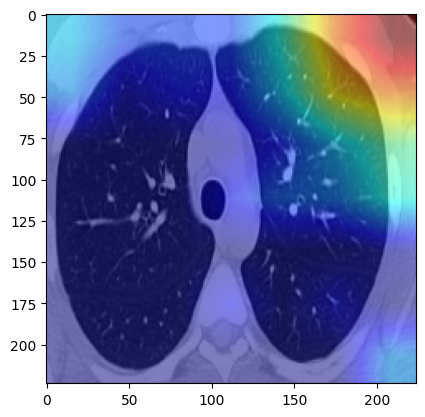

In [175]:
plt.imshow(cam_image)

**GradCAM**

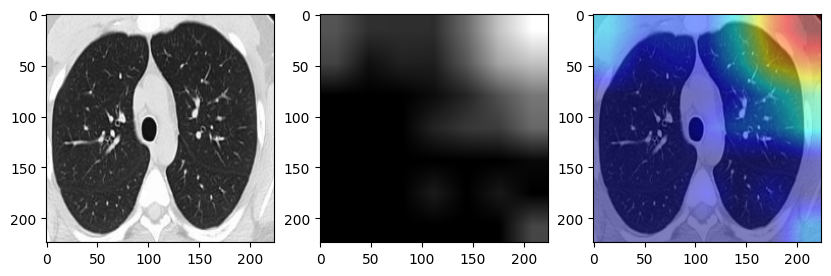

In [176]:
#GradCAM
cam = GradCAM(model=model, target_layers=target_layers)
targets = [ClassifierOutputTarget(category=281)]
grayscale_cam = cam(input_tensor=image_input, targets=targets)
grayscale_cam=grayscale_cam[0]
cam_image = show_cam_on_image(x, grayscale_cam, use_rgb=True)
fig, ax = plt.subplots(1,3, figsize=(10,10))
ax[0].imshow(x)
ax[1].imshow(grayscale_cam, cmap='gray')
ax[2].imshow(cam_image)

**EigenCAM**

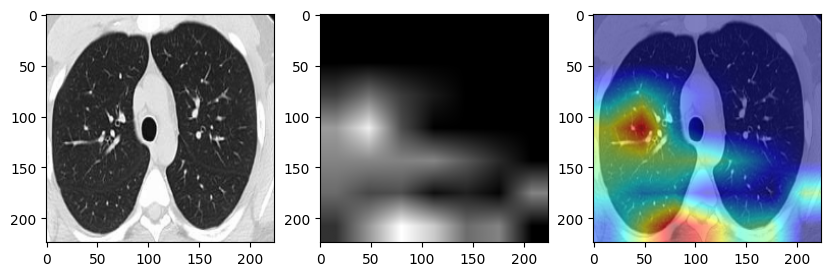

In [177]:
#EigenCAM
cam = EigenCAM(model=model, target_layers=target_layers)
targets = [ClassifierOutputTarget(category=281)]
grayscale_cam = cam(input_tensor=image_input, targets=targets)
grayscale_cam=grayscale_cam[0]
cam_image = show_cam_on_image(x, grayscale_cam, use_rgb=True)
fig, ax = plt.subplots(1,3, figsize=(10,10))
ax[0].imshow(x)
ax[1].imshow(grayscale_cam, cmap='gray')
ax[2].imshow(cam_image)